In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
%matplotlib inline

PROCESSED_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports/charts")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

In [2]:
nav_history = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv", parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_clean.csv", parse_dates=['transaction_date'])
portfolio_holdings = pd.read_csv(PROCESSED_DIR / "09_portfolio_holdings_clean.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")

print("All loaded.")
print(f"nav_history: {nav_history.shape}")
print(f"transactions: {transactions.shape}")
print(f"portfolio_holdings: {portfolio_holdings.shape}")

All loaded.
nav_history: (46000, 4)
transactions: (32778, 13)
portfolio_holdings: (322, 8)


In [3]:
var_results = []

for amfi_code in fund_master['amfi_code']:
    returns = nav_history.loc[
        nav_history['amfi_code'] == amfi_code, 'daily_return_pct'
    ].dropna() / 100

    if len(returns) < 30:
        continue

    # Historical VaR at 95% confidence - 5th percentile of return distribution
    var_95 = np.percentile(returns, 5)

    # CVaR - mean of all returns BELOW the VaR threshold
    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        'amfi_code': amfi_code,
        'var_95_pct': var_95 * 100,   # convert back to percentage
        'cvar_95_pct': cvar_95 * 100,
        'n_observations': len(returns)
    })

var_df = pd.DataFrame(var_results)
var_df = var_df.merge(fund_master[['amfi_code', 'scheme_name', 'category', 'sub_category']], on='amfi_code')
var_df = var_df.sort_values('var_95_pct')  # most negative (worst VaR) first

print(var_df[['scheme_name', 'var_95_pct', 'cvar_95_pct']].head(10))
print(f"\nTotal funds computed: {len(var_df)}")

                                          scheme_name  var_95_pct  cvar_95_pct
3           SBI Small Cap Fund - Direct Plan - Growth   -2.685944    -3.238412
27             Axis Small Cap Fund - Regular - Growth   -2.618842    -3.166729
29             ABSL Small Cap Fund - Regular - Growth   -2.602125    -3.245906
17     Nippon India Small Cap Fund - Regular - Growth   -2.543811    -3.230407
2          SBI Small Cap Fund - Regular Plan - Growth   -2.450705    -3.059526
39              DSP Small Cap Fund - Regular - Growth   -2.348307    -3.103625
32                UTI Mid Cap Fund - Regular - Growth   -1.922028    -2.325086
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   -1.903354    -2.345576
12           ICICI Pru Midcap Fund - Regular - Growth   -1.889179    -2.434207
26                Axis Midcap Fund - Regular - Growth   -1.848028    -2.426006

Total funds computed: 40


In [4]:
var_df.to_csv("../var_cvar_report.csv", index=False)
print("Saved var_cvar_report.csv")

Saved var_cvar_report.csv


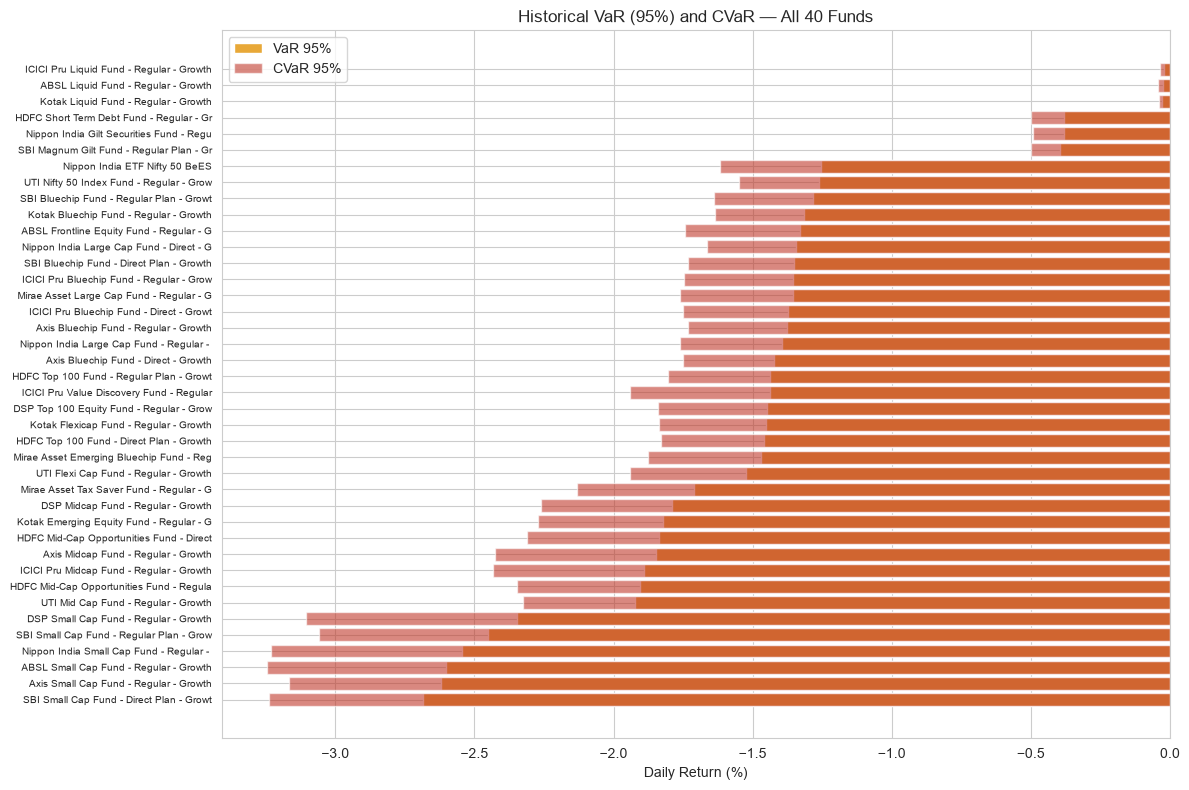

In [5]:
plt.figure(figsize=(12, 8))

# Plot VaR and CVaR side by side for all funds, sorted by VaR
plot_df = var_df.sort_values('var_95_pct')
x = range(len(plot_df))

plt.barh(list(x), plot_df['var_95_pct'], color='#E8A838', label='VaR 95%')
plt.barh(list(x), plot_df['cvar_95_pct'], color='#C0392B', alpha=0.6, label='CVaR 95%')
plt.yticks(list(x), plot_df['scheme_name'].str[:40], fontsize=7)
plt.xlabel("Daily Return (%)")
plt.title("Historical VaR (95%) and CVaR — All 40 Funds")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "11_var_cvar_all_funds.png", dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Select 5 funds representing different categories for an interesting comparison
selected_funds = {
    'SBI Bluechip Fund - Regular Plan - Growth': 119551,        # Large Cap
    'HDFC Top 100 Fund - Regular Plan - Growth': 100016,        # Large Cap
    'SBI Small Cap Fund - Regular Plan - Growth': 119598,       # Small Cap
    'SBI Magnum Gilt Fund - Regular Plan - Growth': 119120,     # Debt/Gilt
    'Kotak Flexicap Fund - Regular - Growth': 120843,           # Flexi Cap
}

print("Selected funds:")
for name, code in selected_funds.items():
    in_data = code in nav_history['amfi_code'].values
    print(f"  {code}: {name} — {'FOUND' if in_data else 'NOT FOUND'}")

Selected funds:
  119551: SBI Bluechip Fund - Regular Plan - Growth — FOUND
  100016: HDFC Top 100 Fund - Regular Plan - Growth — FOUND
  119598: SBI Small Cap Fund - Regular Plan - Growth — FOUND
  119120: SBI Magnum Gilt Fund - Regular Plan - Growth — FOUND
  120843: Kotak Flexicap Fund - Regular - Growth — FOUND


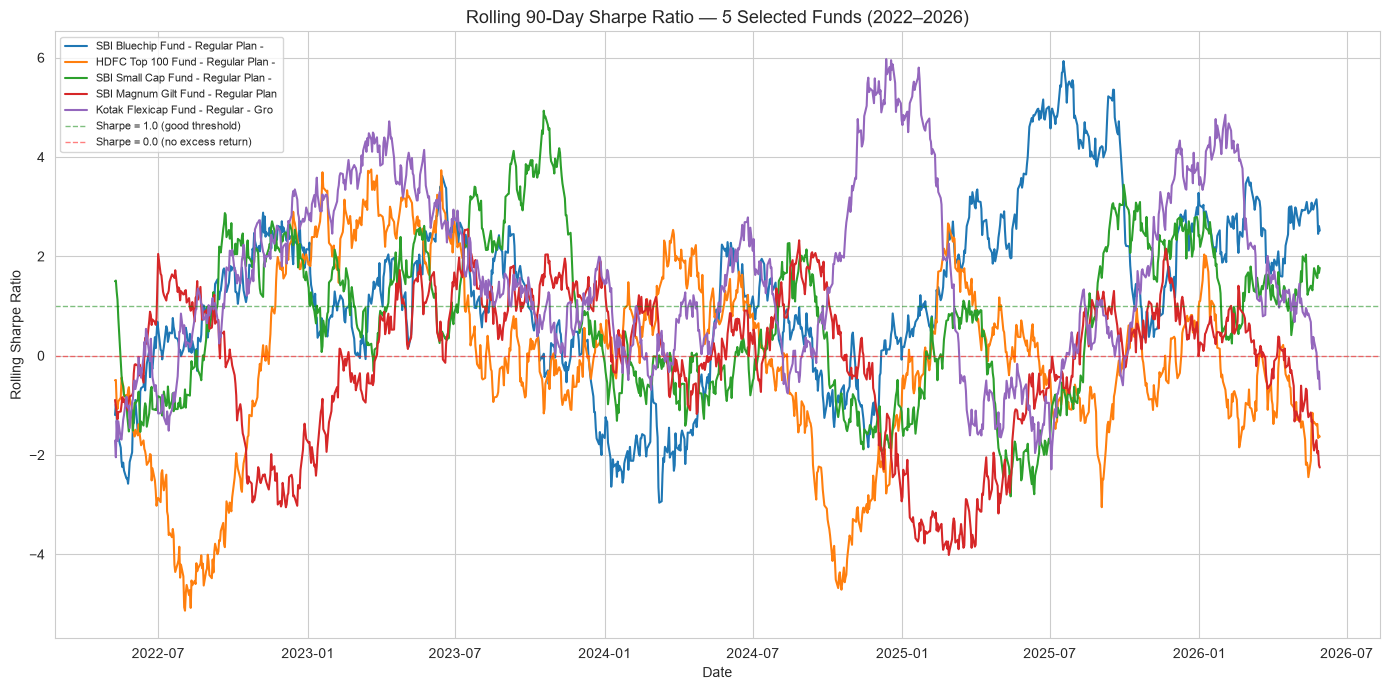

In [7]:
daily_rf = RISK_FREE_RATE / TRADING_DAYS

fig, ax = plt.subplots(figsize=(14, 7))

for fund_name, amfi_code in selected_funds.items():
    fund_returns = nav_history.loc[
        nav_history['amfi_code'] == amfi_code,
        ['date', 'daily_return_pct']
    ].sort_values('date').copy()

    fund_returns['daily_return_pct'] = fund_returns['daily_return_pct'] / 100

    # Rolling 90-day Sharpe
    rolling_mean = fund_returns['daily_return_pct'].rolling(90).mean()
    rolling_std = fund_returns['daily_return_pct'].rolling(90).std()
    rolling_sharpe = ((rolling_mean - daily_rf) / rolling_std) * np.sqrt(TRADING_DAYS)

    ax.plot(fund_returns['date'], rolling_sharpe,
            label=fund_name[:35], linewidth=1.5)

# Add reference lines
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Sharpe = 1.0 (good threshold)')
ax.axhline(y=0.0, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Sharpe = 0.0 (no excess return)')

ax.set_title("Rolling 90-Day Sharpe Ratio — 5 Selected Funds (2022–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(REPORTS_DIR / "12_rolling_sharpe_5_funds.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Find each investor's first transaction date -> their cohort year
first_transaction = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
first_transaction['cohort_year'] = first_transaction['transaction_date'].dt.year
first_transaction.columns = ['investor_id', 'first_transaction_date', 'cohort_year']

print("Cohort distribution:")
print(first_transaction['cohort_year'].value_counts().sort_index())

Cohort distribution:
cohort_year
2024    4803
2025     197
Name: count, dtype: int64


In [9]:
# Merge cohort year back onto all transactions
transactions_with_cohort = transactions.merge(
    first_transaction[['investor_id', 'cohort_year']], on='investor_id', how='left'
)

# Metric 1: Average SIP amount per cohort
sip_only = transactions_with_cohort[transactions_with_cohort['transaction_type'] == 'SIP']
avg_sip_by_cohort = sip_only.groupby('cohort_year')['amount_inr'].mean().round(2)

# Metric 2: Total amount invested per cohort (all transaction types)
total_invested_by_cohort = transactions_with_cohort.groupby('cohort_year')['amount_inr'].sum().round(2)

# Metric 3: Number of unique investors per cohort
investors_per_cohort = first_transaction.groupby('cohort_year')['investor_id'].count()

# Metric 4: Top fund preference per cohort
# Find the most transacted fund (by count) within each cohort
fund_pref = transactions_with_cohort.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='tx_count')
top_fund_per_cohort = fund_pref.loc[fund_pref.groupby('cohort_year')['tx_count'].idxmax()]
top_fund_per_cohort = top_fund_per_cohort.merge(
    fund_master[['amfi_code', 'scheme_name']], on='amfi_code'
)[['cohort_year', 'scheme_name', 'tx_count']]

# Combine into one summary table
cohort_summary = pd.DataFrame({
    'cohort_year': investors_per_cohort.index,
    'num_investors': investors_per_cohort.values,
    'avg_sip_amount': avg_sip_by_cohort.values,
    'total_invested': total_invested_by_cohort.values,
}).merge(top_fund_per_cohort, on='cohort_year')

cohort_summary.to_csv("../cohort_analysis.csv", index=False)
print(cohort_summary)

   cohort_year  num_investors  avg_sip_amount  total_invested  \
0         2024           4803        10996.89      3491125187   
1         2025            197        13505.21        30455243   

                                         scheme_name  tx_count  
0  Mirae Asset Emerging Bluechip Fund - Regular -...       874  
1          SBI Small Cap Fund - Direct Plan - Growth        12  


In [10]:
# Filter to SIP transactions only
sip_transactions = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_transactions = sip_transactions.sort_values(['investor_id', 'transaction_date'])

# Compute gap between consecutive SIPs per investor
sip_transactions['prev_date'] = sip_transactions.groupby('investor_id')['transaction_date'].shift(1)
sip_transactions['gap_days'] = (sip_transactions['transaction_date'] - sip_transactions['prev_date']).dt.days

# Keep only investors with 6+ SIP transactions
sip_count = sip_transactions.groupby('investor_id')['transaction_date'].count()
eligible_investors = sip_count[sip_count >= 6].index
sip_eligible = sip_transactions[sip_transactions['investor_id'].isin(eligible_investors)]

# Compute average gap per investor
avg_gap = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']
avg_gap['sip_count'] = sip_eligible.groupby('investor_id')['transaction_date'].count().values
avg_gap['at_risk'] = avg_gap['avg_gap_days'] > 35

# Summary stats
print(f"Investors with 6+ SIP transactions: {len(avg_gap)}")
print(f"At-risk investors (avg gap > 35 days): {avg_gap['at_risk'].sum()}")
print(f"At-risk rate: {avg_gap['at_risk'].mean() * 100:.1f}%")
print(f"\nAverage gap distribution:")
print(avg_gap['avg_gap_days'].describe().round(2))

avg_gap.to_csv("../sip_continuity.csv", index=False)
print("\nSaved sip_continuity.csv")

Investors with 6+ SIP transactions: 1362
At-risk investors (avg gap > 35 days): 1332
At-risk rate: 97.8%

Average gap distribution:
count    1362.00
mean       64.89
std        15.59
min        19.80
25%        53.64
50%        64.69
75%        75.57
max       102.60
Name: avg_gap_days, dtype: float64

Saved sip_continuity.csv


In [11]:
# Look at actual gap distribution in more detail
print("Gap distribution (all eligible investors):")
print(pd.cut(avg_gap['avg_gap_days'],
             bins=[0, 35, 45, 60, 75, 90, 120],
             labels=['<35 (healthy)', '35-45', '45-60', '60-75', '75-90', '90+']).value_counts().sort_index())

# Also check: what does a single investor's SIP timeline look like?
sample_investor = sip_eligible['investor_id'].iloc[0]
sample_sips = sip_eligible[sip_eligible['investor_id'] == sample_investor][['transaction_date', 'gap_days']].head(10)
print(f"\nSample investor ({sample_investor}) SIP dates:")
print(sample_sips)

Gap distribution (all eligible investors):
avg_gap_days
<35 (healthy)     30
35-45             99
45-60            426
60-75            460
75-90            252
90+               95
Name: count, dtype: int64

Sample investor (INV000004) SIP dates:
      transaction_date  gap_days
4773        2024-03-16       NaN
6418        2024-04-11      26.0
8271        2024-05-09      28.0
12003       2024-07-07      59.0
28749       2025-03-29     265.0
31897       2025-05-17      49.0


In [12]:
# Check: are at-risk investors concentrated in any particular state or age group?
at_risk_investors = avg_gap[avg_gap['at_risk'] == True]['investor_id']
not_at_risk = avg_gap[avg_gap['at_risk'] == False]['investor_id']

at_risk_profile = transactions[transactions['investor_id'].isin(at_risk_investors)].drop_duplicates('investor_id')[['age_group', 'state', 'city_tier']].value_counts(['age_group']).head(5)
healthy_profile = transactions[transactions['investor_id'].isin(not_at_risk)].drop_duplicates('investor_id')[['age_group']].value_counts().head(5)

print("At-risk investors by age group:")
print(at_risk_profile)
print("\nHealthy SIP investors by age group:")
print(healthy_profile)

At-risk investors by age group:
age_group
26-35        553
36-45        326
18-25        206
46-55        151
56+           96
Name: count, dtype: int64

Healthy SIP investors by age group:
age_group
36-45        10
26-35         8
18-25         6
56+           4
46-55         2
Name: count, dtype: int64


In [13]:
import sys
sys.path.append('..')

fund_data = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv").merge(
    pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")[
        ['amfi_code', 'sharpe_ratio', 'return_3yr_pct', 'expense_ratio_pct']
    ], on='amfi_code'
)

risk_mapping = {
    'Low': ['Low', 'Moderate'],
    'Moderate': ['Moderate', 'Moderately High'],
    'High': ['High', 'Very High']
}

for appetite, grades in risk_mapping.items():
    filtered = fund_data[fund_data['risk_category'].isin(grades)]
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'risk_category', 'sharpe_ratio', 'return_3yr_pct']
    ].reset_index(drop=True)
    top3.index += 1
    print(f"\nRisk Appetite: {appetite.upper()}")
    print("-" * 50)
    print(top3.to_string())
    print()


Risk Appetite: LOW
--------------------------------------------------
                                scheme_name                fund_house risk_category  sharpe_ratio  return_3yr_pct
1  ICICI Pru Liquid Fund - Regular - Growth       ICICI Prudential MF           Low          7.68            7.68
2      Kotak Liquid Fund - Regular - Growth         Kotak Mahindra MF           Low          6.18            6.18
3       ABSL Liquid Fund - Regular - Growth  Aditya Birla Sun Life MF           Low          5.14            5.14


Risk Appetite: MODERATE
--------------------------------------------------
                                     scheme_name           fund_house risk_category  sharpe_ratio  return_3yr_pct
1      HDFC Top 100 Fund - Regular Plan - Growth     HDFC Mutual Fund      Moderate          1.06           14.84
2  Mirae Asset Large Cap Fund - Regular - Growth       Mirae Asset MF      Moderate          1.06           14.81
3      ICICI Pru Bluechip Fund - Direct - Growth  ICIC

In [14]:
# HHI only makes sense for equity funds (debt funds don't hold equity sectors)
equity_holdings = portfolio_holdings.merge(
    fund_master[['amfi_code', 'scheme_name', 'category', 'sub_category']],
    on='amfi_code'
)
equity_holdings = equity_holdings[equity_holdings['category'] == 'Equity']

# Compute sector weights as % of total portfolio per fund
# Note: weight_pct in the data may already be % within that fund's portfolio
# Let's verify they sum to roughly 100% per fund first
weight_check = equity_holdings.groupby('amfi_code')['weight_pct'].sum()
print("Weight sum per fund (should be ~100%):")
print(weight_check.describe().round(2))

Weight sum per fund (should be ~100%):
count     34.00
mean     100.00
std        0.01
min       99.98
25%       99.99
50%      100.00
75%      100.01
max      100.02
Name: weight_pct, dtype: float64


In [15]:
# Aggregate weight_pct to sector level first (a fund may hold multiple stocks in the same sector)
sector_weights = equity_holdings.groupby(['amfi_code', 'scheme_name', 'sector'])['weight_pct'].sum().reset_index()

# HHI = sum of squared sector weights per fund
sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2
hhi_df = sector_weights.groupby(['amfi_code', 'scheme_name'])['weight_sq'].sum().reset_index()
hhi_df.columns = ['amfi_code', 'scheme_name', 'hhi']

# Merge sub_category for context
hhi_df = hhi_df.merge(fund_master[['amfi_code', 'sub_category']], on='amfi_code')
hhi_df = hhi_df.sort_values('hhi', ascending=False).reset_index(drop=True)

print("Top 10 most concentrated funds (highest HHI):")
print(hhi_df.head(10)[['scheme_name', 'sub_category', 'hhi']].to_string())
print("\nBottom 5 most diversified funds (lowest HHI):")
print(hhi_df.tail(5)[['scheme_name', 'sub_category', 'hhi']].to_string())
print(f"\nHHI range: {hhi_df['hhi'].min():.1f} to {hhi_df['hhi'].max():.1f}")

Top 10 most concentrated funds (highest HHI):
                                          scheme_name sub_category        hhi
0               Axis Bluechip Fund - Regular - Growth    Large Cap  2967.6909
1       Mirae Asset Tax Saver Fund - Regular - Growth         ELSS  2549.9194
2   HDFC Mid-Cap Opportunities Fund - Direct - Growth      Mid Cap  2531.5500
3               UTI Flexi Cap Fund - Regular - Growth    Flexi Cap  2513.8255
4                  DSP Midcap Fund - Regular - Growth      Mid Cap  2410.7664
5            ICICI Pru Midcap Fund - Regular - Growth      Mid Cap  2386.9504
6                      Nippon India ETF Nifty 50 BeES    Index/ETF  2374.9677
7           SBI Small Cap Fund - Direct Plan - Growth    Small Cap  2323.6120
8   ICICI Pru Value Discovery Fund - Regular - Growth        Value  2314.6434
9  HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap  2276.4744

Bottom 5 most diversified funds (lowest HHI):
                                       scheme_nam

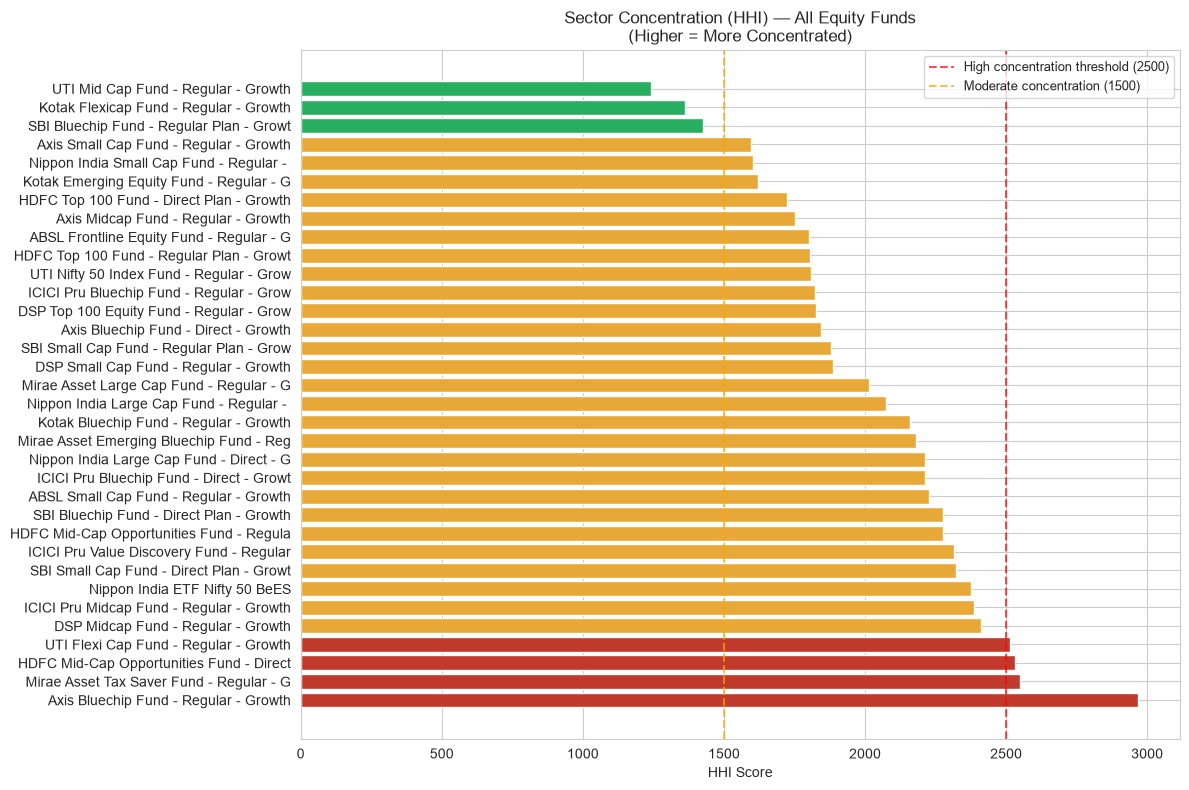

In [16]:
plt.figure(figsize=(12, 8))
colors = ['#C0392B' if h > 2500 else '#E8A838' if h > 1500 else '#27AE60'
          for h in hhi_df['hhi']]

plt.barh(
    hhi_df['scheme_name'].str[:40],
    hhi_df['hhi'],
    color=colors
)

# Add a reference line - HHI > 2500 = highly concentrated (red zone)
plt.axvline(x=2500, color='red', linestyle='--', alpha=0.7, label='High concentration threshold (2500)')
plt.axvline(x=1500, color='orange', linestyle='--', alpha=0.7, label='Moderate concentration (1500)')

plt.xlabel("HHI Score")
plt.title("Sector Concentration (HHI) — All Equity Funds\n(Higher = More Concentrated)", fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "13_sector_hhi_concentration.png", dpi=150, bbox_inches='tight')
plt.show()

## Advanced Analytics — 5 Key Insights

1. **Small Cap funds carry the highest tail risk**: The top 5 worst VaR (95%) values all
   belong to Small Cap funds, with SBI Small Cap Direct showing the worst daily tail loss
   at -2.69% VaR and -3.24% CVaR. In practical terms, on the worst 5% of trading days,
   investors in this fund can expect to lose more than 2.69% of their portfolio value in
   a single day — consistent with the fund's -52% max drawdown found in Day 4.

2. **Rolling Sharpe ratios are highly unstable across all fund types**: No fund maintains
   a consistently positive 90-day rolling Sharpe ratio throughout the full 2022-2026
   period — all 5 selected funds oscillate between positive and negative values, crossing
   the zero line multiple times. The SBI Magnum Gilt Fund shows the most extreme swings
   (reaching below -4), consistent with the Sharpe instability for debt funds near the
   risk-free rate documented in Day 4.

3. **Newer investors (2025 cohort) invest 23% more per SIP** (₹13,505 avg) than the
   established 2024 cohort (₹10,997 avg), though this is based on only 197 investors and
   should be interpreted cautiously. Both cohorts show Mirae Asset and SBI funds as their
   top fund preferences respectively, suggesting brand recognition drives fund selection
   regardless of when the investor joined.

4. **SIP continuity is broadly poor across all demographics**: 97.8% of investors with
   6+ SIP transactions show average gaps exceeding 35 days, with a mean gap of 64.89 days
   (roughly bi-monthly). This irregularity is not concentrated in any particular age group
   — all demographics show similar at-risk rates — suggesting systematic rather than
   demographic-specific SIP dropout patterns in this dataset.

5. **Portfolio concentration (HHI) varies widely even within the same fund category**:
   Axis Bluechip Fund (Large Cap) is the most concentrated portfolio in the dataset
   (HHI = 2,968), while UTI Mid Cap Fund is the most diversified (HHI = 1,240) — despite
   both being equity funds. Counterintuitively, Small Cap funds tend to score lower HHI
   (more diversified by sector) than some Large Cap and Mid Cap funds, likely because
   Small Cap mandates require broader stock selection across many smaller companies
   rather than concentrated bets on large sector leaders.